Question - What characteristics contribute the most to the success of players in relation to gender
*   Dataset - FIFA
*   csv Files - female_players_16 to female_players_22; players_16 to players_22





Variables Looked At

*   Alyce - body type
*   Riya -


*   Meena -
*   Avery - attribute importance by gender





*Title* -Analysis of Fifa Players' Success by Gender






*   Alyce - 2609119
*   Meena - 2615440


*   Avery - 2709760
*   Riya -





Introduction

In our analysis, we will study data on FIFA players to learn about factors that affect the players' success. We assess the "player success" through the overall rating of a player, indicated as `overall_avg`.

The key question our project aims to answer is: **Which characteristics affect player success the most with respect to gender?**

To answer the above questions, it is necessary to evaluate different variables in both males and females, such as body type, physical attributes, and skill-based attribute. This will help determine whether similar factors affect the performance of male and female players, or whether there are differences in the correlation between the two groups.


Data Description
We use the female players and male players' data sets from FIFA 16 to FIFA 22.

This dataset contains information on the players, including information like the overall rating of the player, potential, age, height, weight, nationality, work rate, body type, and skills based attributes like pace, shooting, passing, dribbling, defending, reaction, stamina, and composure.

Since we have the data separated based on years, we join them into one data set using `sofifa_id`, which is used to identify players. The average value of each of the numeric attributes is calculated for the period. For instance, `overall_avg` refers to the average overall rating for each player.


In [107]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import statistics as stat

In [108]:
#import data

#Import Female Data Sets
female1_df = pd.read_csv("_final_project/2-FIFA/female_players_16.csv")
female2_df = pd.read_csv("_final_project/2-FIFA/female_players_17.csv")
female3_df = pd.read_csv("_final_project/2-FIFA/female_players_18.csv")
female4_df = pd.read_csv("_final_project/2-FIFA/female_players_19.csv")
female5_df = pd.read_csv("_final_project/2-FIFA/female_players_20.csv")
female6_df = pd.read_csv("_final_project/2-FIFA/female_players_21.csv")
female7_df = pd.read_csv("_final_project/2-FIFA/female_players_22.csv")

#Import Male Data Sets
male1_df = pd.read_csv("_final_project/2-FIFA/players_16.csv")
male2_df = pd.read_csv("_final_project/2-FIFA/players_17.csv")
male3_df = pd.read_csv("_final_project/2-FIFA/players_18.csv")
male4_df = pd.read_csv("_final_project/2-FIFA/players_19.csv")
male5_df = pd.read_csv("_final_project/2-FIFA/players_20.csv")
male6_df = pd.read_csv("_final_project/2-FIFA/players_21.csv")
male7_df = pd.read_csv("_final_project/2-FIFA/players_22.csv")

/var/folders/qp/0rf5j_cd511f7kqzl7318x9m0000gn/T/ipykernel_23845/3693434762.py:13: DtypeWarning: Columns (104) have mixed types. Specify dtype option on import or set low_memory=False.
  male1_df = pd.read_csv("_final_project/2-FIFA/players_16.csv")
/var/folders/qp/0rf5j_cd511f7kqzl7318x9m0000gn/T/ipykernel_23845/3693434762.py:15: DtypeWarning: Columns (81,82,83,84,85) have mixed types. Specify dtype option on import or set low_memory=False.
  male3_df = pd.read_csv("_final_project/2-FIFA/players_18.csv")
/var/folders/qp/0rf5j_cd511f7kqzl7318x9m0000gn/T/ipykernel_23845/3693434762.py:19: DtypeWarning: Columns (25,108) have mixed types. Specify dtype option on import or set low_memory=False.
  male7_df = pd.read_csv("_final_project/2-FIFA/players_22.csv")


In [109]:
#calculations for counting the number of rows, etc.
list = [female2_df, female3_df, female4_df, female5_df, female6_df, female7_df, male1_df, male2_df, male3_df, male4_df, male5_df, male6_df, male7_df]

for x in list:
    if set(female1_df.columns) == set(x.columns):
        print("T")
    else:
        print("FALSE")

T
T
T
T
T
T
T
T
T
T
T
T
T


Merging Procedures

In [110]:
#merging code

#merging female datasets
columns = ["sofifa_id", "short_name", "long_name", "player_positions", "overall", "potential", "age", "height_cm", "weight_kg", "nationality_id", "work_rate", "body_type", "pace", "shooting", "passing", "dribbling", "defending", "attacking_crossing", "attacking_finishing", "attacking_heading_accuracy", "attacking_short_passing", "attacking_volleys", "skill_dribbling", "skill_curve", "skill_fk_accuracy", "skill_long_passing", "skill_ball_control", "movement_acceleration", "movement_sprint_speed", "movement_agility", "movement_reactions", "movement_balance", "power_shot_power", "power_jumping", "power_stamina", "power_strength", "power_long_shots", "mentality_aggression", "mentality_interceptions", "mentality_positioning", "mentality_vision", "mentality_penalties", "mentality_composure", "defending_marking_awareness", "defending_standing_tackle", "defending_sliding_tackle", "goalkeeping_diving", "goalkeeping_handling", "goalkeeping_kicking", "goalkeeping_positioning", "goalkeeping_reflexes", "goalkeeping_speed"]

female1_df = female1_df[columns]
female2_df = female2_df[columns]
female3_df = female3_df[columns]
female4_df = female4_df[columns]
female5_df = female5_df[columns]
female6_df = female6_df[columns]
female7_df = female7_df[columns]


female_datasets = [female1_df, female2_df, female3_df, female4_df, female5_df, female6_df, female7_df]
numbers = ["1", "2", "3", "4", "5", "6", "7"]
renamed_female_dfs = []

for dataset, number in zip(female_datasets, numbers):
    dataset = dataset.rename(columns = {
        column: column + "_" + number for column in dataset.columns if column != "sofifa_id"
    })
    renamed_female_dfs.append(dataset)

merged_female_df = renamed_female_dfs[0]
for dataset in renamed_female_dfs[1: ]:
    merged_female_df = merged_female_df.merge(dataset, on = "sofifa_id", how = "inner")

merged_female_df["gender"] = "female"
print(merged_female_df.shape)
merged_female_df.head()

(64, 359)


,sofifa_id,short_name_1,long_name_1,player_positions_1,overall_1,potential_1,age_1,height_cm_1,weight_kg_1,nationality_id_1,...,defending_marking_awareness_7,defending_standing_tackle_7,defending_sliding_tackle_7,goalkeeping_diving_7,goalkeeping_handling_7,goalkeeping_kicking_7,goalkeeping_positioning_7,goalkeeping_reflexes_7,goalkeeping_speed_7,gender
0,226328,M. Rapinoe,Megan Anna Rapinoe,"LM, CM",90,90,29,170,60,95,...,46,46,48,15,12,14,14,11,NaN,female
1,226359,C. Sinclair,Christine Margaret Sinclair,"ST, LW, RW, CAM",88,88,32,175,67,70,...,32,19,16,17,9,7,12,8,NaN,female
2,226177,B. Sauerbrunn,Rebecca Elizabeth Sauerbrunn,CB,86,87,30,170,64,95,...,89,88,89,15,12,7,10,11,NaN,female
3,226308,D. Marozsán,Dzsenifer Marozsán,"CAM, CM",86,91,23,171,50,21,...,51,46,53,8,10,15,9,12,NaN,female
4,226330,T. Heath,Tobin Powell Heath,"LM, CAM, RM",85,88,27,168,59,95,...,31,38,39,12,7,7,16,8,NaN,female


In [111]:
#merging

#merging male datasets
columns = ["sofifa_id", "short_name", "long_name", "player_positions", "overall", "potential", "age", "height_cm", "weight_kg", "nationality_id", "work_rate", "body_type", "pace", "shooting", "passing", "dribbling", "defending", "attacking_crossing", "attacking_finishing", "attacking_heading_accuracy", "attacking_short_passing", "attacking_volleys", "skill_dribbling", "skill_curve", "skill_fk_accuracy", "skill_long_passing", "skill_ball_control", "movement_acceleration", "movement_sprint_speed", "movement_agility", "movement_reactions", "movement_balance", "power_shot_power", "power_jumping", "power_stamina", "power_strength", "power_long_shots", "mentality_aggression", "mentality_interceptions", "mentality_positioning", "mentality_vision", "mentality_penalties", "mentality_composure", "defending_marking_awareness", "defending_standing_tackle", "defending_sliding_tackle", "goalkeeping_diving", "goalkeeping_handling", "goalkeeping_kicking", "goalkeeping_positioning", "goalkeeping_reflexes", "goalkeeping_speed"]

male1_df = male1_df[columns]
male2_df = male2_df[columns]
male3_df = male3_df[columns]
male4_df = male4_df[columns]
male5_df = male5_df[columns]
male6_df = male6_df[columns]
male7_df = male7_df[columns]


male_datasets = [male1_df, male2_df, male3_df, male4_df, male5_df, male6_df, male7_df]
numbers = ["1", "2", "3", "4", "5", "6", "7"]
renamed_male_dfs = []

for dataset, number in zip(male_datasets, numbers):
    dataset = dataset.rename(columns = {
        column: column + "_" + number for column in dataset.columns if column != "sofifa_id"
    })
    renamed_male_dfs.append(dataset)

merged_male_df = renamed_male_dfs[0]
for dataset in renamed_male_dfs[1: ]:
    merged_male_df = merged_male_df.merge(dataset, on = "sofifa_id", how = "inner")

merged_male_df["gender"] = "male"
print(merged_male_df.shape)
merged_male_df.head()

(4063, 359)


,sofifa_id,short_name_1,long_name_1,player_positions_1,overall_1,potential_1,age_1,height_cm_1,weight_kg_1,nationality_id_1,...,defending_marking_awareness_7,defending_standing_tackle_7,defending_sliding_tackle_7,goalkeeping_diving_7,goalkeeping_handling_7,goalkeeping_kicking_7,goalkeeping_positioning_7,goalkeeping_reflexes_7,goalkeeping_speed_7,gender
0,158023,L. Messi,Lionel Andrés Messi Cuccittini,"RW, CF",94,95,28,170,72,52,...,20,35,24,6,11,15,14,8,NaN,male
1,20801,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"LW, LM",93,93,30,185,80,38,...,24,32,24,7,11,15,14,11,NaN,male
2,167495,M. Neuer,Manuel Peter Neuer,GK,90,90,29,193,92,21,...,17,10,11,88,88,91,89,88,56.0,male
3,176580,L. Suárez,Luis Alberto Suárez Díaz,ST,90,90,28,182,85,60,...,42,45,38,27,25,31,33,37,NaN,male
4,41236,Z. Ibrahimović,Zlatan Ibrahimović,ST,89,89,33,195,95,46,...,28,37,24,13,15,10,9,12,NaN,male


Data Cleaning

In [112]:
#data cleaning code
#cleaning code female dataset
merged_female_df.dtypes

columns = [ "overall", "potential", "age", "height_cm", "weight_kg", "nationality_id", "pace", "shooting", "passing", "dribbling", "defending", "attacking_crossing", "attacking_finishing", "attacking_heading_accuracy", "attacking_short_passing", "attacking_volleys", "skill_dribbling", "skill_curve", "skill_fk_accuracy", "skill_long_passing", "skill_ball_control", "movement_acceleration", "movement_sprint_speed", "movement_agility", "movement_reactions", "movement_balance", "power_shot_power", "power_jumping", "power_stamina", "power_strength", "power_long_shots", "mentality_aggression", "mentality_interceptions", "mentality_positioning", "mentality_vision", "mentality_penalties", "mentality_composure","defending_marking_awareness", "defending_standing_tackle", "defending_sliding_tackle", "goalkeeping_diving", "goalkeeping_handling", "goalkeeping_kicking", "goalkeeping_positioning", "goalkeeping_reflexes", "goalkeeping_speed"]
numbers = ["1", "2", "3", "4", "5", "6", "7"]

for column in columns:
    columns_variable = [column + "_" + num for num in numbers]
    merged_female_df[column + "_avg"] = merged_female_df[columns_variable].mean(axis = 1)

merged_female_df = merged_female_df.drop_duplicates()
merged_female_df = merged_female_df.dropna(subset = ["overall_avg"])

print(merged_female_df.shape)
merged_female_df.head()

(64, 405)


,sofifa_id,short_name_1,long_name_1,player_positions_1,overall_1,potential_1,age_1,height_cm_1,weight_kg_1,nationality_id_1,...,mentality_composure_avg,defending_marking_awareness_avg,defending_standing_tackle_avg,defending_sliding_tackle_avg,goalkeeping_diving_avg,goalkeeping_handling_avg,goalkeeping_kicking_avg,goalkeeping_positioning_avg,goalkeeping_reflexes_avg,goalkeeping_speed_avg
0,226328,M. Rapinoe,Megan Anna Rapinoe,"LM, CM",90,90,29,170,60,95,...,90.666667,44.000000,44.857143,46.857143,13.857143,10.857143,12.857143,12.857143,9.857143,NaN
1,226359,C. Sinclair,Christine Margaret Sinclair,"ST, LW, RW, CAM",88,88,32,175,67,70,...,93.333333,34.285714,17.857143,14.857143,15.857143,7.857143,5.857143,10.857143,6.857143,NaN
2,226177,B. Sauerbrunn,Rebecca Elizabeth Sauerbrunn,CB,86,87,30,170,64,95,...,85.000000,88.428571,87.571429,87.571429,13.857143,10.857143,5.857143,8.857143,9.857143,NaN
3,226308,D. Marozsán,Dzsenifer Marozsán,"CAM, CM",86,91,23,171,50,21,...,86.333333,47.714286,44.857143,51.857143,6.857143,8.857143,13.857143,7.857143,10.857143,NaN
4,226330,T. Heath,Tobin Powell Heath,"LM, CAM, RM",85,88,27,168,59,95,...,89.666667,30.714286,36.857143,37.857143,10.857143,5.857143,5.857143,14.857143,6.857143,NaN


In [113]:
#cleaning code male dataset
merged_male_df.dtypes

columns = [ "overall", "potential", "age", "height_cm", "weight_kg", "nationality_id", "pace", "shooting", "passing", "dribbling", "defending", "attacking_crossing", "attacking_finishing", "attacking_heading_accuracy", "attacking_short_passing", "attacking_volleys", "skill_dribbling", "skill_curve", "skill_fk_accuracy", "skill_long_passing", "skill_ball_control", "movement_acceleration", "movement_sprint_speed", "movement_agility", "movement_reactions", "movement_balance", "power_shot_power", "power_jumping", "power_stamina", "power_strength", "power_long_shots", "mentality_aggression", "mentality_interceptions", "mentality_positioning", "mentality_vision", "mentality_penalties", "mentality_composure","defending_marking_awareness", "defending_standing_tackle", "defending_sliding_tackle", "goalkeeping_diving", "goalkeeping_handling", "goalkeeping_kicking", "goalkeeping_positioning", "goalkeeping_reflexes", "goalkeeping_speed"]
numbers = ["1", "2", "3", "4", "5", "6", "7"]

for column in columns:
    columns_variable = [column + "_" + num for num in numbers]
    merged_male_df[column + "_avg"] = merged_male_df[columns_variable].mean(axis = 1)

merged_male_df = merged_male_df.drop_duplicates()
merged_male_df = merged_male_df.dropna(subset = ["overall_avg"])

print(merged_male_df.shape)
merged_male_df.head()

(4063, 405)


,sofifa_id,short_name_1,long_name_1,player_positions_1,overall_1,potential_1,age_1,height_cm_1,weight_kg_1,nationality_id_1,...,mentality_composure_avg,defending_marking_awareness_avg,defending_standing_tackle_avg,defending_sliding_tackle_avg,goalkeeping_diving_avg,goalkeeping_handling_avg,goalkeeping_kicking_avg,goalkeeping_positioning_avg,goalkeeping_reflexes_avg,goalkeeping_speed_avg
0,158023,L. Messi,Lionel Andrés Messi Cuccittini,"RW, CF",94,95,28,170,72,52,...,95.666667,22.428571,30.571429,24.714286,6.000000,11.000000,15.000000,14.000000,8.0,NaN
1,20801,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"LW, LM",93,93,30,185,80,38,...,93.500000,24.857143,31.428571,23.428571,7.000000,11.000000,15.000000,14.000000,11.0,NaN
2,167495,M. Neuer,Manuel Peter Neuer,GK,90,90,29,193,92,21,...,70.000000,14.000000,10.000000,11.000000,88.285714,88.142857,92.142857,88.571429,88.0,58.142857
3,176580,L. Suárez,Luis Alberto Suárez Díaz,ST,90,90,28,182,85,60,...,84.666667,44.000000,45.000000,38.000000,27.000000,25.000000,31.000000,33.000000,37.0,NaN
4,41236,Z. Ibrahimović,Zlatan Ibrahimović,ST,89,89,33,195,95,46,...,90.333333,22.428571,38.714286,25.285714,13.000000,15.000000,10.000000,9.000000,12.0,NaN


## Alyce - Body Type Analysis 



In [114]:
# Choose body type and average overall rating
female_body_df = merged_female_df[["body_type_7", "overall_avg"]]
male_body_df = merged_male_df[["body_type_7", "overall_avg"]]

# Rename the body type column for clarity
female_body_df = female_body_df.rename(columns={"body_type_7": "body_type"})
male_body_df = male_body_df.rename(columns={"body_type_7": "body_type"})

# Average overall rating for each body type
female_body_summary = female_body_df.groupby("body_type")["overall_avg"].mean()
male_body_summary = male_body_df.groupby("body_type")["overall_avg"].mean()

# Sort from highest to lowest average overall rating
female_body_summary = female_body_summary.sort_values(ascending=False)
male_body_summary = male_body_summary.sort_values(ascending=False)

female_body_summary

body_type
Lean (185+)         88.285714
Unique              87.571429
Stocky (170-185)    85.428571
Lean (170-)         81.928571
Normal (170-185)    81.795031
Stocky (170-)       79.285714
Lean (170-185)      78.900000
Normal (170-)       78.812500
Name: overall_avg, dtype: float64

In [115]:
male_body_summary

body_type
Unique              83.333805
Normal (170-)       71.696241
Lean (170-)         71.527473
Lean (185+)         71.033156
Stocky (185+)       71.018963
Normal (170-185)    70.768615
Stocky (170-)       70.626728
Normal (185+)       70.561453
Lean (170-185)      70.324963
Stocky (170-185)    70.047619
Name: overall_avg, dtype: float64

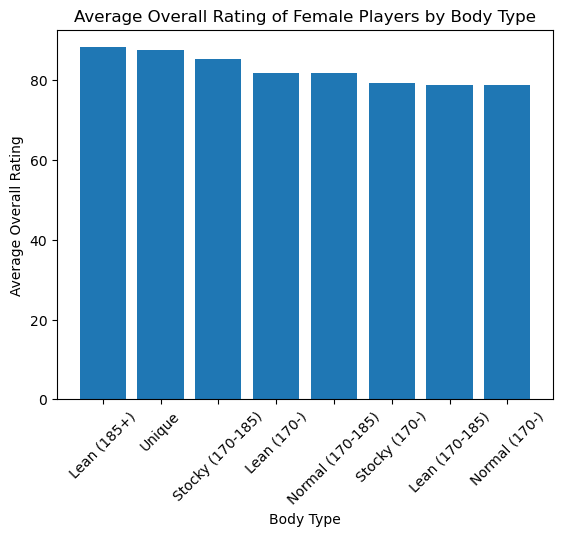

In [ ]:
plt.bar(female_body_summary.index, female_body_summary)

plt.title("Average Overall Rating of Female
 Players by Body Type")
plt.xlabel("Body Type")
plt.ylabel("Average Overall Rating")
plt.xticks(rotation=45)
plt.show()

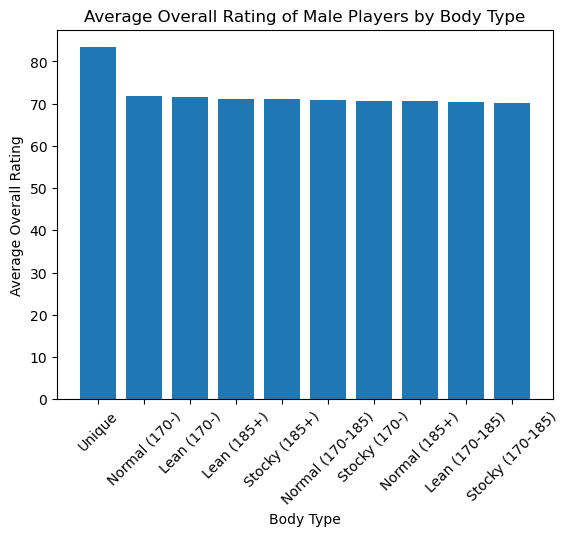

In [117]:
plt.bar(male_body_summary.index, male_body_summary)

plt.title("Average Overall Rating of Male Players by Body Type")
plt.xlabel("Body Type")
plt.ylabel("Average Overall Rating")
plt.xticks(rotation=45)
plt.show()

## Avery - Attribute Importance by Gender

My contribution to the group project involves assessing which attributes of players are most predictive of their success. Success is defined using the variable `overall_avg`, which reflects how good an average player is in general terms.

The main research question to be addressed is:

**Which player characteristics are most strongly related to average overall rating, and do these relationships vary for male and female players?**

To address this question, I will compare average attributes between `overall_avg` and various averages of player attributes, such as pace, shooting, passing, dribbling, defending, reactions, composure, stamina, age, height, and weight. This comparison will be made separately for men and women.



In [118]:
# First, I will use the already-cleaned female and male datasets
female_players = merged_female_df
male_players = merged_male_df

# Then sort each dataset by average overall rating from highest to lowest
female_sorted = female_players.sort_values(by="overall_avg", ascending=False)
male_sorted = male_players.sort_values(by="overall_avg", ascending=False)

# I will select the top 10 players for each gender
female_top10 = female_sorted.iloc[:10, :]
male_top10 = male_sorted.iloc[:10, :]

female_top10[["short_name_1", "overall_avg"]]


,short_name_1,overall_avg
0,M. Rapinoe,91.000000
1,C. Sinclair,88.714286
3,D. Marozsán,88.571429
12,W. Renard,88.285714
18,A. Henry,88.285714
4,T. Heath,87.571429
5,A. Morgan,87.571429
2,B. Sauerbrunn,87.285714
24,S. Kerr,87.142857
13,J. Johnston,86.428571


In [119]:
male_top10[["short_name_1", "overall_avg"]]

,short_name_1,overall_avg
0,L. Messi,93.428571
1,Cristiano Ronaldo,93.000000
9,Neymar,91.142857
2,M. Neuer,90.142857
19,R. Lewandowski,90.000000
3,L. Suárez,89.857143
29,K. De Bruyne,89.571429
12,Sergio Ramos,89.000000
5,E. Hazard,88.857143
16,L. Modrić,88.571429


In [120]:
# Now, I will compare the top 10 female players to all female players
female_attribute_comparison = pd.DataFrame({
    "attribute": [
        "Pace",
        "Shooting",
        "Passing",
        "Dribbling",
        "Defending",
        "Reactions",
        "Composure",
        "Stamina",
        "Age",
        "Height",
        "Weight"
    ],
    
    "all_female_players_avg": [
        female_players["pace_avg"].mean(),
        female_players["shooting_avg"].mean(),
        female_players["passing_avg"].mean(),
        female_players["dribbling_avg"].mean(),
        female_players["defending_avg"].mean(),
        female_players["movement_reactions_avg"].mean(),
        female_players["mentality_composure_avg"].mean(),
        female_players["power_stamina_avg"].mean(),
        female_players["age_avg"].mean(),
        female_players["height_cm_avg"].mean(),
        female_players["weight_kg_avg"].mean()
    ],
    
    "top_10_female_players_avg": [
        female_top10["pace_avg"].mean(),
        female_top10["shooting_avg"].mean(),
        female_top10["passing_avg"].mean(),
        female_top10["dribbling_avg"].mean(),
        female_top10["defending_avg"].mean(),
        female_top10["movement_reactions_avg"].mean(),
        female_top10["mentality_composure_avg"].mean(),
        female_top10["power_stamina_avg"].mean(),
        female_top10["age_avg"].mean(),
        female_top10["height_cm_avg"].mean(),
        female_top10["weight_kg_avg"].mean()
    ]
})

# The difference shows how much higher or lower the top 10 players are
female_attribute_comparison["difference"] = (
    female_attribute_comparison["top_10_female_players_avg"] -
    female_attribute_comparison["all_female_players_avg"]
)

# Sort the positive difference from largest to smallest
female_attribute_comparison = female_attribute_comparison.sort_values(
    by="difference",
    ascending=False
)

female_attribute_comparison

,attribute,all_female_players_avg,top_10_female_players_avg,difference
6,Composure,70.492188,86.483333,15.991146
7,Stamina,72.504464,80.142857,7.638393
1,Shooting,65.673854,71.642857,5.969003
2,Passing,69.827493,75.042857,5.215364
3,Dribbling,73.989218,79.042857,5.053639
5,Reactions,78.227679,83.271429,5.043750
0,Pace,73.447439,75.742857,2.295418
9,Height,169.910714,172.014286,2.103571
8,Age,27.531250,28.900000,1.368750
10,Weight,62.216518,62.442857,0.226339


In [121]:
# Next, I will compare the top 10 male players to all male players

male_attribute_comparison = pd.DataFrame({
    "attribute": [
        "Pace",
        "Shooting",
        "Passing",
        "Dribbling",
        "Defending",
        "Reactions",
        "Composure",
        "Stamina",
        "Age",
        "Height",
        "Weight"
    ],
    
    "all_male_players_avg": [
        male_players["pace_avg"].mean(),
        male_players["shooting_avg"].mean(),
        male_players["passing_avg"].mean(),
        male_players["dribbling_avg"].mean(),
        male_players["defending_avg"].mean(),
        male_players["movement_reactions_avg"].mean(),
        male_players["mentality_composure_avg"].mean(),
        male_players["power_stamina_avg"].mean(),
        male_players["age_avg"].mean(),
        male_players["height_cm_avg"].mean(),
        male_players["weight_kg_avg"].mean()
    ],
    
    "top_10_male_players_avg": [
        male_top10["pace_avg"].mean(),
        male_top10["shooting_avg"].mean(),
        male_top10["passing_avg"].mean(),
        male_top10["dribbling_avg"].mean(),
        male_top10["defending_avg"].mean(),
        male_top10["movement_reactions_avg"].mean(),
        male_top10["mentality_composure_avg"].mean(),
        male_top10["power_stamina_avg"].mean(),
        male_top10["age_avg"].mean(),
        male_top10["height_cm_avg"].mean(),
        male_top10["weight_kg_avg"].mean()
    ]
})

# The difference shows how much higher or lower the top 10 players are
male_attribute_comparison["difference"] = (
    male_attribute_comparison["top_10_male_players_avg"] -
    male_attribute_comparison["all_male_players_avg"]
)

# Similarly to female's, sort the positive difference from largest to smallest
male_attribute_comparison = male_attribute_comparison.sort_values(
    by="difference",
    ascending=False
)

male_attribute_comparison

,attribute,all_male_players_avg,top_10_male_players_avg,difference
1,Shooting,56.834829,83.682540,26.847711
5,Reactions,67.297704,89.742857,22.445153
6,Composure,64.370170,86.766667,22.396497
3,Dribbling,66.749067,87.650794,20.901727
2,Passing,62.348170,82.349206,20.001037
0,Pace,69.598229,82.158730,12.560501
7,Stamina,67.917654,77.757143,9.839489
8,Age,26.274287,30.000000,3.725713
10,Weight,76.286382,76.914286,0.627903
9,Height,182.050912,180.171429,-1.879484


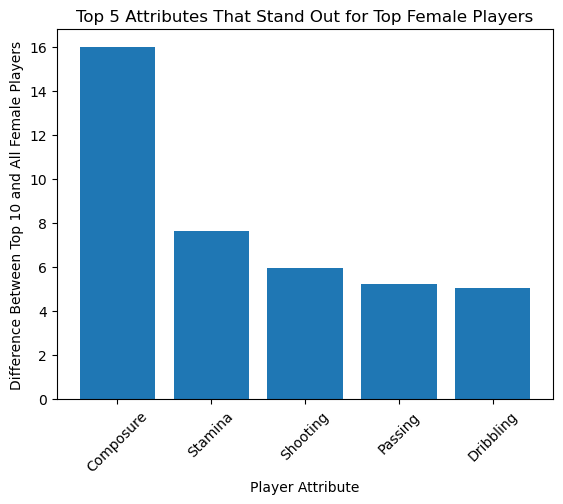

In [122]:
# Graph bar charts showing the top 5 characteristics that stand out most for top female players

female_top5_attributes = female_attribute_comparison.iloc[:5, :]

plt.bar(
    female_top5_attributes["attribute"],
    female_top5_attributes["difference"]
)

plt.title("Top 5 Attributes That Stand Out for Top Female Players")
plt.xlabel("Player Attribute")
plt.ylabel("Difference Between Top 10 and All Female Players")
plt.xticks(rotation=45)
plt.show()

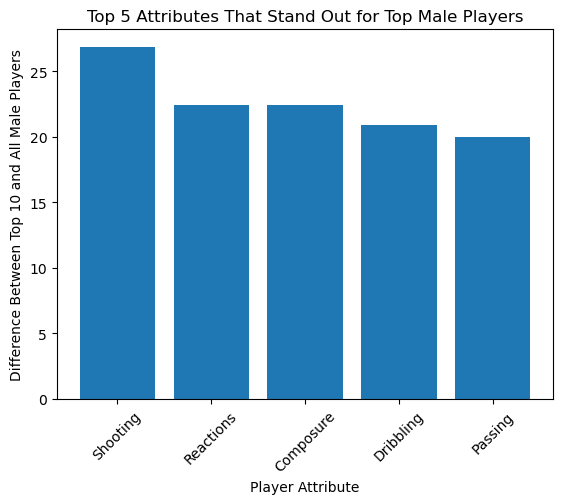

In [123]:
# Graph bar charts showing the top 5 characteristics that stand out most for top male players

male_top5_attributes = male_attribute_comparison.iloc[:5, :]

plt.bar(
    male_top5_attributes["attribute"],
    male_top5_attributes["difference"]
)

plt.title("Top 5 Attributes That Stand Out for Top Male Players")
plt.xlabel("Player Attribute")
plt.ylabel("Difference Between Top 10 and All Male Players")
plt.xticks(rotation=45)
plt.show()

In [124]:
#Using the actual top 5 results

female_top5 = female_top5_attributes["attribute"]
male_top5 = male_top5_attributes["attribute"]

print("Avery's Interpretation")
print()
print("The five attributes that stand out most among the top 10 highest-rated female players are:")
print(female_top5)
print()
print("The five attributes that stand out most among the top 10 highest-rated male players are:")
print(male_top5)
print()
print("This indicates that player performance does not depend solely on one attribute.")
print("Rather, top players tend to excel in multiple physical and psychological factors.")
print("Comparing male and female players helps show whether the same characteristics stand out across gender.")

Avery's Interpretation

The five attributes that stand out most among the top 10 highest-rated female players are:
6    Composure
7      Stamina
1     Shooting
2      Passing
3    Dribbling
Name: attribute, dtype: object

The five attributes that stand out most among the top 10 highest-rated male players are:
1     Shooting
5    Reactions
6    Composure
3    Dribbling
2      Passing
Name: attribute, dtype: object

This indicates that player performance does not depend solely on one attribute.
Rather, top players tend to excel in multiple physical and psychological factors.
Comparing male and female players helps show whether the same characteristics stand out across gender.
